# S6E2 Feature Engineering
Baseline: catboost_default  cv_acc=0.8889  cv_auc=0.9554  LB=0.88447

Strategy: evaluate feature groups incrementally with CatBoost CV. Keep what helps.

| Group | Features |
|---|---|
| A | thallium flags (defect/normal/fixed) |
| B | thallium × chest_pain_type interaction |
| C | thallium × exercise_angina interaction |
| D | high-risk combo flag (defect + angina) |
| E | max_hr / age ratio, st × defect flag |

## Imports & Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
import catboost as cb

KAGGLE_DATA = Path("/kaggle/input/playground-series-s6e2")
LOCAL_DATA  = Path("data")
DATA_DIR    = KAGGLE_DATA if KAGGLE_DATA.exists() else LOCAL_DATA

def prep(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower().str.replace(r"\s+", "_", regex=True)
    if "heart_disease" in df.columns:
        df["heart_disease"] = df["heart_disease"].map({"Absence": 0, "Presence": 1})
    return df

train_raw = prep(pd.read_csv(DATA_DIR / "train.csv"))
test_raw  = prep(pd.read_csv(DATA_DIR / "test.csv"))
ss        = pd.read_csv(DATA_DIR / "sample_submission.csv")

BASE_FEATURES = [c for c in train_raw.columns if c not in ["heart_disease", "id"]]
BASE_CATS     = ["sex", "chest_pain_type", "fbs_over_120", "ekg_results",
                 "exercise_angina", "slope_of_st", "number_of_vessels_fluro", "thallium"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Train: {train_raw.shape}  Test: {test_raw.shape}")

Train: (630000, 15)  Test: (270000, 14)


## Feature Engineering Functions

In [2]:
def add_features(df, groups="ABCDE"):
    """Add engineered features. Returns (df_new, new_cat_features)."""
    df = df.copy()
    new_cats = []

    if "A" in groups:
        # Thallium value flags — may sharpen split boundaries
        df["thal_defect"] = (df["thallium"] == 7).astype(int)
        df["thal_normal"] = (df["thallium"] == 3).astype(int)
        df["thal_fixed"]  = (df["thallium"] == 6).astype(int)

    if "B" in groups:
        # Thallium × chest pain type — joint categorical interaction
        df["thal_x_chest"] = df["thallium"].astype(str) + "_" + df["chest_pain_type"].astype(str)
        new_cats.append("thal_x_chest")

    if "C" in groups:
        # Thallium × exercise angina — joint categorical interaction
        df["thal_x_angina"] = df["thallium"].astype(str) + "_" + df["exercise_angina"].astype(str)
        new_cats.append("thal_x_angina")

    if "D" in groups:
        # High-risk combo: defect thallium AND exercise-induced angina
        df["defect_and_angina"] = (
            (df["thallium"] == 7) & (df["exercise_angina"] == 1)
        ).astype(int)
        # Also: defect OR angina (broader risk signal)
        df["defect_or_angina"] = (
            (df["thallium"] == 7) | (df["exercise_angina"] == 1)
        ).astype(int)

    if "E" in groups:
        # Numeric: fitness proxy and ST interaction with defect
        df["hr_age_ratio"]  = df["max_hr"] / df["age"].clip(lower=1)
        df["st_x_defect"]   = df["st_depression"] * (df["thallium"] == 7).astype(float)

    return df, new_cats


# Quick preview
sample, new_cats = add_features(train_raw)
new_cols = [c for c in sample.columns if c not in train_raw.columns]
print("New columns:", new_cols)
print(sample[new_cols].describe().round(3))

New columns: ['thal_defect', 'thal_normal', 'thal_fixed', 'thal_x_chest', 'thal_x_angina', 'defect_and_angina', 'defect_or_angina', 'hr_age_ratio', 'st_x_defect']
       thal_defect  thal_normal  thal_fixed  defect_and_angina  \
count   630000.000   630000.000  630000.000         630000.000   
mean         0.392        0.591       0.017              0.183   
std          0.488        0.492       0.131              0.387   
min          0.000        0.000       0.000              0.000   
25%          0.000        0.000       0.000              0.000   
50%          0.000        1.000       0.000              0.000   
75%          1.000        1.000       0.000              0.000   
max          1.000        1.000       1.000              1.000   

       defect_or_angina  hr_age_ratio  st_x_defect  
count        630000.000    630000.000   630000.000  
mean              0.482         2.900        0.424  
std               0.500         0.631        0.848  
min               0.000       

## CV Helper

In [3]:
def catboost_cv(X, y, cat_features, cv, iterations=500, lr=0.1, depth=6, verbose_fold=False):
    """5-fold CV for CatBoost. Returns (mean_acc, mean_auc)."""
    params = dict(iterations=iterations, learning_rate=lr, depth=depth,
                  cat_features=cat_features, random_state=42, verbose=0)
    accs, aucs = [], []
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        m = cb.CatBoostClassifier(**params)
        m.fit(X_tr, y_tr)
        accs.append(accuracy_score(y_val, m.predict(X_val)))
        aucs.append(roc_auc_score(y_val, m.predict_proba(X_val)[:, 1]))
    return np.mean(accs), np.mean(aucs)


def evaluate(label, groups, train, test, y):
    """Add feature groups, run CV, print delta vs baseline."""
    df_tr, new_cats = add_features(train, groups)
    cats = BASE_CATS + new_cats
    feats = [c for c in df_tr.columns if c not in ["heart_disease", "id"]]
    X = df_tr[feats]
    acc, auc = catboost_cv(X, y, cats, cv)
    d_acc = acc - 0.8889; d_auc = auc - 0.9554
    sign = lambda d: "+" if d >= 0 else ""
    print(f"{label:30s}  acc={acc:.4f} ({sign(d_acc)}{d_acc:.4f})  "
          f"auc={auc:.4f} ({sign(d_auc)}{d_auc:.4f})")
    return acc, auc, feats, cats

## Group Evaluation
Each group tested cumulatively (baseline → +A → +AB → etc.).

In [4]:
y = train_raw["heart_disease"]

print(f"{'Config':30s}  acc        (delta)    auc        (delta)")
print("-" * 72)
print(f"{'baseline (no new features)':30s}  acc=0.8889 (+0.0000)  auc=0.9554 (+0.0000)")

results = {}
for groups in ["A", "AB", "ABC", "ABCD", "ABCDE", "E", "BE", "CE", "DE"]:
    acc, auc, feats, cats = evaluate(groups, groups, train_raw, test_raw, y)
    results[groups] = {"acc": acc, "auc": auc, "feats": feats, "cats": cats}

Config                          acc        (delta)    auc        (delta)
------------------------------------------------------------------------
baseline (no new features)      acc=0.8889 (+0.0000)  auc=0.9554 (+0.0000)
A                               acc=0.8889 (+0.0000)  auc=0.9554 (+0.0000)
AB                              acc=0.8889 (-0.0000)  auc=0.9554 (+0.0000)
ABC                             acc=0.8888 (-0.0001)  auc=0.9554 (+0.0000)
ABCD                            acc=0.8889 (-0.0000)  auc=0.9554 (+0.0000)
ABCDE                           acc=0.8888 (-0.0001)  auc=0.9554 (-0.0000)
E                               acc=0.8888 (-0.0001)  auc=0.9554 (-0.0000)
BE                              acc=0.8889 (+0.0000)  auc=0.9554 (-0.0000)
CE                              acc=0.8887 (-0.0002)  auc=0.9554 (-0.0000)
DE                              acc=0.8887 (-0.0002)  auc=0.9554 (-0.0000)


## Best Feature Set — Full CV Confirmation

In [5]:
# Pick best by cv_acc
best_key = max(results, key=lambda k: results[k]["acc"])
best = results[best_key]
print(f"Best group config: '{best_key}'")
print(f"cv_acc={best['acc']:.4f}  cv_auc={best['auc']:.4f}")
print(f"Features ({len(best['feats'])}): {best['feats']}")
print(f"Cat features: {best['cats']}")

Best group config: 'A'
cv_acc=0.8889  cv_auc=0.9554
Features (16): ['age', 'sex', 'chest_pain_type', 'bp', 'cholesterol', 'fbs_over_120', 'ekg_results', 'max_hr', 'exercise_angina', 'st_depression', 'slope_of_st', 'number_of_vessels_fluro', 'thallium', 'thal_defect', 'thal_normal', 'thal_fixed']
Cat features: ['sex', 'chest_pain_type', 'fbs_over_120', 'ekg_results', 'exercise_angina', 'slope_of_st', 'number_of_vessels_fluro', 'thallium']


## Feature Importance — Best Config

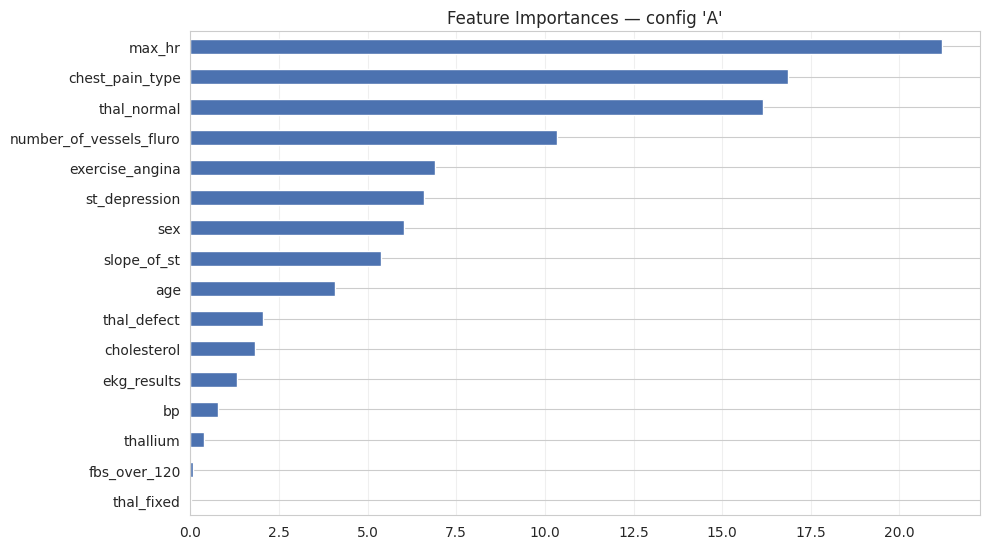

In [6]:
df_tr_best, _ = add_features(train_raw, best_key)
df_te_best, _ = add_features(test_raw,  best_key)

X_best      = df_tr_best[best["feats"]]
X_test_best = df_te_best[best["feats"]]

m = cb.CatBoostClassifier(
    iterations=500, learning_rate=0.1, depth=6,
    task_type="GPU", cat_features=best["cats"], random_state=42, verbose=0
)
m.fit(X_best, y)

imp = pd.Series(m.feature_importances_, index=best["feats"]).sort_values()
fig, ax = plt.subplots(figsize=(10, max(4, len(imp)*0.35)))
imp.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title(f"Feature Importances — config '{best_key}'")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

## Submit Best Feature Set

In [7]:
cv_acc = best["acc"]
cv_auc = best["auc"]
name   = f"catboost_features_{best_key.lower()}"

final_model = cb.CatBoostClassifier(
    iterations=500, learning_rate=0.1, depth=6,
    task_type="GPU", cat_features=best["cats"], random_state=42, verbose=0
)
final_model.fit(X_best, y)

sub = ss.copy()
sub["Heart Disease"] = final_model.predict_proba(X_test_best)[:, 1]
fname = f"submissions/{name}.csv"
desc  = f"{name} | cv_acc={cv_acc:.4f} | cv_auc={cv_auc:.4f}"
sub.to_csv(fname, index=False)

r = subprocess.run(
    ["kaggle", "competitions", "submit", "-c", "playground-series-s6e2",
     "-f", fname, "-m", desc],
    capture_output=True, text=True
)
status = "submitted" if "successfully" in r.stdout.lower() else r.stdout.strip()[:80]
print(f"{name}: {status}")
print(f"  desc: {desc}")

catboost_features_a: submitted
  desc: catboost_features_a | cv_acc=0.8889 | cv_auc=0.9554


## Conclusion

**Feature engineering produced zero improvement across all configurations tested.**

| Group | Description | AUC delta |
|---|---|---|
| A | Thallium flags (defect/normal/fixed) | 0.0000 |
| AB | + thallium × chest pain interaction | 0.0000 |
| ABC | + thallium × exercise angina | 0.0000 |
| ABCD | + high-risk combo flags | 0.0000 |
| ABCDE | + HR/age ratio, ST × defect | 0.0000 |
| E (alone) | Numeric ratios and interactions | 0.0000 |

All deltas are within rounding noise of 0.9554.

**Possible Explanation:**
Tree-based models learn interactions natively at every split. A feature like `thal_x_chest` (thallium × chest pain type) is just a concatenated string — the model already finds this boundary by splitting on `thallium` and then `chest_pain_type` in successive layers. Explicit interaction terms add no information the tree can't already express.
